# Wholesale Credit Portfolio Stress Testing  
## Full Notebook — Merton PDs, Factor Calibration, Correlated Defaults, and Portfolio Credit Risk

### Project goal

This notebook builds a simplified but rigorous **wholesale credit portfolio stress-testing framework** using real public-company data.

The project has four stages:

1. **Construct a corporate borrower universe** using real public companies.
2. **Estimate firm-level structural default risk** using a simplified Merton-style distance-to-default framework.
3. **Calibrate market and sector factor exposures** using stock and ETF returns.
4. **Simulate correlated portfolio defaults** to estimate portfolio loss distribution, Credit VaR, Expected Shortfall, economic capital, and sector tail-risk attribution.

### Important modelling note

This is a **pedagogical credit-risk prototype**, not a production-calibrated bank model. The Merton PDs, factor loadings, EADs, and LGDs use transparent approximations so the mechanics are easy to audit. The notebook therefore emphasizes methodology, diagnostics, and scenario comparison rather than regulatory capital calibration.

## 1. Structural-credit intuition

The Merton model treats a firm's equity as a call option on its assets.

Let:

$$
A_t = \text{firm asset value}
$$

$$
K = \text{debt face value or default barrier}
$$

Default occurs when:

$$
A_T < K
$$

Equity holders receive:

$$
E_T = (A_T - K)^+
$$

The true asset value is not directly observable, so this project uses observable public-company data:

| Model concept | Practical proxy |
|---|---|
| Equity value $(E)$ | Market capitalization |
| Default barrier $(K)$ | Total debt |
| Equity volatility $(\sigma_E)$ | Annualized stock-return volatility |
| Market factor | SPY return |
| Sector factor | Sector ETF return |

## 2. Portfolio-credit intuition

Single-firm PDs are not enough for portfolio credit risk.

Defaults cluster because firms share exposure to:

- market-wide recessions,
- sector downturns,
- idiosyncratic firm shocks.

We use a multi-factor latent asset-return model:

$$
Y_i = \beta_i M + \gamma_i I_{s(i)} + \sqrt{1-\beta_i^2-\gamma_i^2}\epsilon_i
$$

A firm defaults if:

$$
Y_i < \Phi^{-1}(PD_i)
$$

## 3. Install and import packages

In [16]:
# Run once if yfinance is not installed.
# %pip install yfinance --upgrade --no-cache-dir

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import yfinance as yf
from scipy.stats import norm
from scipy.optimize import least_squares
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("yfinance version:", yf.__version__)

yfinance version: 1.4.0


## 4. Define company universe and factor ETFs

Each ticker is treated as a corporate borrower, not as an equity holding. The stock data is used because public companies provide observable market capitalization and equity volatility, which are useful proxies for firm-level structural credit risk.

The sector ETF mapping gives each borrower an industry risk factor. Later, this lets the model distinguish broad market shocks from sector-specific shocks.

In [17]:
sector_etfs = {
    "Technology": "XLK",
    "Energy": "XLE",
    "Industrials": "XLI",
    "Consumer": "XLY",
    "Healthcare": "XLV",
    "Financials": "XLF",
    "Real Estate": "XLRE",
}

# Default example portfolio. Replace this with your own portfolio_input dataframe or CSV path.
company_universe = {
    "Technology": ["AAPL", "MSFT", "NVDA", "CRM", "ORCL", "ADBE", "CSCO", "INTC"],
    "Energy": ["XOM", "CVX", "COP", "EOG", "SLB", "MPC", "PSX", "VLO"],
    "Industrials": ["CAT", "BA", "GE", "HON", "UNP", "UPS", "LMT", "DE"],
    "Consumer": ["AMZN", "WMT", "HD", "MCD", "SBUX", "NKE", "TGT", "COST"],
    "Healthcare": ["JNJ", "PFE", "MRK", "UNH", "ABBV", "TMO", "ABT", "LLY"],
    "Financials": ["JPM", "BAC", "GS", "MS", "C", "WFC", "USB", "PNC"],
    "Real Estate": ["PLD", "AMT", "EQIX", "SPG", "O", "PSA", "CCI", "DLR"],
}

# Option A: leave as None to use company_universe above.
# Option B: set to a dataframe with at least a ticker column.
# Option C: set to a CSV path with at least a ticker column.
# Supported optional columns include sector_group/sector, sector_etf, ead/exposure, and lgd.
portfolio_input = None

# Example custom input with the minimum one-company portfolio:
# portfolio_input = pd.DataFrame({
#     "ticker": ["AAPL"],
#     "sector_group": ["Technology"],
#     "ead": [100_000_000],
#     "lgd": [0.45],
# })


def standardize_portfolio_input(portfolio_input=None, company_universe=None, sector_etfs=None):
    sector_etfs = sector_etfs or {}

    if portfolio_input is None:
        if not company_universe:
            raise ValueError("Provide either portfolio_input or company_universe.")
        rows = []
        for sector_name, sector_tickers in company_universe.items():
            for ticker in sector_tickers:
                rows.append({
                    "ticker": ticker,
                    "sector_group": sector_name,
                    "sector_etf": sector_etfs.get(sector_name, "SPY"),
                })
        portfolio_df = pd.DataFrame(rows)
    elif isinstance(portfolio_input, (str, bytes)):
        portfolio_df = pd.read_csv(portfolio_input)
    else:
        portfolio_df = pd.DataFrame(portfolio_input).copy()

    if portfolio_df.empty:
        raise ValueError("Portfolio must contain at least one company.")

    normalized_columns = {col.lower().strip(): col for col in portfolio_df.columns}
    column_aliases = {
        "ticker": ["ticker", "symbol", "borrower_ticker", "company_ticker", "name"],
        "sector_group": ["sector_group", "sector", "industry_group", "gics_sector"],
        "sector_etf": ["sector_etf", "factor_etf", "sector_factor", "etf"],
        "ead": ["ead", "exposure", "exposure_at_default", "loan_amount", "commitment"],
        "lgd": ["lgd", "loss_given_default"],
    }

    rename_map = {}
    for standard_name, aliases in column_aliases.items():
        for alias in aliases:
            if alias in normalized_columns:
                rename_map[normalized_columns[alias]] = standard_name
                break
    portfolio_df = portfolio_df.rename(columns=rename_map)

    if "ticker" not in portfolio_df.columns:
        raise ValueError("Portfolio input must include a ticker/symbol column.")

    portfolio_df["ticker"] = portfolio_df["ticker"].astype(str).str.upper().str.strip()
    portfolio_df = portfolio_df.loc[portfolio_df["ticker"].ne("")].drop_duplicates("ticker")

    if portfolio_df.empty:
        raise ValueError("Portfolio must contain at least one valid ticker.")

    if "sector_group" not in portfolio_df.columns:
        portfolio_df["sector_group"] = "User Portfolio"
    portfolio_df["sector_group"] = portfolio_df["sector_group"].fillna("User Portfolio").astype(str).str.strip()
    portfolio_df.loc[portfolio_df["sector_group"].eq(""), "sector_group"] = "User Portfolio"

    if "sector_etf" not in portfolio_df.columns:
        portfolio_df["sector_etf"] = portfolio_df["sector_group"].map(sector_etfs)
    else:
        portfolio_df["sector_etf"] = portfolio_df["sector_etf"].fillna(
            portfolio_df["sector_group"].map(sector_etfs)
        )
    portfolio_df["sector_etf"] = portfolio_df["sector_etf"].fillna("SPY").astype(str).str.upper().str.strip()
    portfolio_df.loc[portfolio_df["sector_etf"].eq(""), "sector_etf"] = "SPY"

    for numeric_col in ["ead", "lgd"]:
        if numeric_col in portfolio_df.columns:
            portfolio_df[numeric_col] = pd.to_numeric(portfolio_df[numeric_col], errors="coerce")

    if "lgd" in portfolio_df.columns and portfolio_df["lgd"].dropna().gt(1).any():
        portfolio_df["lgd"] = np.where(
            portfolio_df["lgd"] > 1,
            portfolio_df["lgd"] / 100,
            portfolio_df["lgd"],
        )

    ordered_cols = ["ticker", "sector_group", "sector_etf"]
    optional_cols = [col for col in ["ead", "lgd"] if col in portfolio_df.columns]
    remaining_cols = [col for col in portfolio_df.columns if col not in ordered_cols + optional_cols]
    return portfolio_df[ordered_cols + optional_cols + remaining_cols].reset_index(drop=True)


company_df = standardize_portfolio_input(
    portfolio_input=portfolio_input,
    company_universe=company_universe,
    sector_etfs=sector_etfs,
)

print("Number of companies:", len(company_df))
print("Number of sector groups:", company_df["sector_group"].nunique())
company_df.head()


## 4.1 Flexible portfolio input contract

The notebook now accepts a minimum portfolio of one company. A user portfolio can be supplied as a dataframe or CSV path through `portfolio_input`. The only required field is a ticker-like column such as `ticker` or `symbol`. Optional fields such as sector, sector ETF, EAD, and LGD are standardized automatically. Missing sector ETFs fall back to `SPY`; missing EAD and LGD receive transparent model defaults.

## 5. Flatten tickers and download price data

The universe is stored by sector for readability, but market data APIs require a flat list of tickers. We also download SPY and sector ETFs because those returns become explanatory factors in the later factor-loading regression.

This data supports two tasks: estimating each firm's equity volatility and estimating each firm's sensitivity to market and sector movements.

In [18]:
tickers = company_df["ticker"].dropna().astype(str).str.upper().unique().tolist()
factor_tickers = ["SPY"] + company_df["sector_etf"].dropna().astype(str).str.upper().unique().tolist()
factor_tickers = sorted(set(factor_tickers))
all_tickers = sorted(set(tickers + factor_tickers))

if len(tickers) < 1:
    raise ValueError("Portfolio must contain at least one company ticker.")

print("Number of company tickers:", len(tickers))
print("Number of factor tickers:", len(factor_tickers))
print("Total unique tickers:", len(all_tickers))
print("Sector factors:", factor_tickers)


Number of company tickers: 56
Number of factor tickers: 8
Total unique tickers: 64


In [19]:
prices = yf.download(
    all_tickers,
    start="2019-01-01",
    end="2024-12-31",
    auto_adjust=True,
    progress=False
)["Close"]

prices.head()

c:\Users\Binhe Jia\AppData\Local\Programs\Python\Python310\lib\site-packages\yfinance\scrapers\history.py:396: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
c:\Users\Binhe Jia\AppData\Local\Programs\Python\Python310\lib\site-packages\yfinance\scrapers\history.py:396: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
c:\Users\Binhe Jia\AppData\Local\Programs\Python\Python310\lib\site-packages\yfinance\scrapers\history.py:396: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
c:\Users\Binhe Jia\AppData\Local\Programs\Python\Python310\lib\site-packages

Ticker,AAPL,ABBV,ABT,ADBE,AMT,AXP,BA,BAC,BLK,BMY,C,CAT,COP,COST,CRM,CSCO,CVX,DLR,EOG,EQIX,GE,GS,HD,HON,INTC,JNJ,JPM,LMT,LOW,MCD,MPC,MRK,MS,MSFT,NKE,NVDA,O,ORCL,PFE,PLD,PSA,PSX,RTX,SBUX,SLB,SPG,SPY,TGT,TMO,UNH,UNP,UPS,VLO,WELL,WFC,WMT,XLE,XLF,XLI,XLK,XLRE,XLV,XLY,XOM
2019-01-02,37.469204,64.789452,60.801216,224.570007,129.213226,86.626450,314.645142,20.945084,325.040863,39.592640,41.436657,108.023605,49.032200,184.861801,133.588699,34.472195,79.872673,80.475807,67.100441,303.811676,37.317703,145.391678,144.203796,106.343987,40.518051,103.790977,80.836510,218.160980,80.339287,148.797729,47.206020,57.638222,32.141224,94.193138,67.154190,3.376984,42.167549,40.505611,28.818663,46.672779,144.748489,65.383217,57.343624,54.597122,30.385843,110.938271,224.382538,53.870190,215.256561,215.453156,117.373749,71.712982,56.109116,53.431431,38.257412,27.913780,21.123749,20.933620,57.430740,29.032198,23.826702,75.273300,46.654301,49.664761
2019-01-03,33.737000,62.654709,57.931751,215.699997,129.988129,84.935570,302.100555,20.609426,315.492218,34.341022,40.685795,103.860947,48.103859,180.943558,128.513199,33.218510,78.342903,80.070251,66.626488,300.287445,37.364048,143.261841,141.025436,104.924248,38.289040,102.141716,79.687675,212.680725,79.381516,147.817322,46.517414,56.456326,31.568422,90.727936,65.966324,3.172956,42.542034,40.111469,28.012396,46.296326,147.523834,64.477989,54.791485,52.228874,30.712566,110.844185,219.028137,53.132355,208.144150,209.577713,113.029099,69.676872,55.099209,54.416073,37.955860,27.770231,20.914248,20.463013,55.683170,27.567015,23.936829,73.744843,45.644150,48.902203
2019-01-04,35.177197,64.673256,59.585194,226.190002,130.507507,88.762794,317.822601,21.465355,327.044128,35.688175,42.675186,109.536507,49.318424,186.197998,135.963837,34.714836,79.966476,81.739182,69.551628,307.101440,38.152122,147.944046,145.215790,108.594604,40.638531,103.855965,82.625412,218.416412,81.732414,150.673950,48.796967,58.156734,32.857250,94.947662,67.689156,3.376240,42.528423,41.840267,28.652065,47.466614,145.891357,67.401390,56.665878,53.960510,31.929642,112.531685,226.364639,53.862080,217.552200,212.028778,117.382233,72.103943,57.185860,54.217548,39.080593,27.943684,21.625837,21.142786,57.794468,28.788786,24.180683,75.944725,47.154701,50.705231
2019-01-07,35.098904,65.617188,60.477524,229.259995,131.315399,89.244621,318.823395,21.448568,327.953949,36.845047,43.046753,109.604897,49.101830,186.884109,140.162201,34.949394,81.005577,82.823212,69.988548,307.717773,40.516354,148.763809,148.076294,109.199608,40.827862,103.189774,82.682823,220.921677,83.282249,152.313599,49.279797,57.516212,33.183430,95.068741,68.659401,3.554980,42.405857,42.503120,28.805328,48.235901,145.483170,67.868820,56.639412,53.960510,32.811810,113.714981,228.149445,56.497196,220.485428,212.435822,118.114876,71.860519,57.245251,54.860729,38.827938,28.272644,21.947315,21.168934,58.264622,29.046242,24.385206,76.236305,48.220978,50.968891
2019-01-08,35.768005,65.922142,59.751415,232.679993,132.799240,89.680962,330.891937,21.406612,332.127380,36.525391,42.930641,110.921219,49.759403,188.283447,143.611557,35.232487,80.651985,83.712296,70.736511,314.106506,39.681923,148.214478,148.787231,108.973732,41.086052,105.586510,82.526932,222.396774,85.006218,152.634720,49.762615,57.943230,32.976593,95.758026,69.575226,3.466478,43.025482,42.888290,28.938597,49.839962,148.095276,67.809479,57.661301,54.002941,33.220219,116.431099,230.292969,56.440460,225.616211,215.276184,128.422806,71.867882,57.445747,55.829464,38.746445,28.470020,22.117088,21.186361,59.063011,29.289658,24.809977,76.828224,48.754112,51.339474


## 6. Convert prices into returns

Returns are used instead of prices because volatility, covariance, correlation, and regression betas are defined on returns. The first return observation is missing because a percentage change requires a previous price.

The return matrix is the foundation for both single-firm volatility estimation and portfolio correlation modeling.

In [20]:
returns = prices.pct_change().dropna()

print("Return matrix shape:", returns.shape)
preview_cols = [col for col in ["SPY"] + tickers[:3] + factor_tickers[:3] if col in returns.columns]
returns[preview_cols].head()


Return matrix shape: (1508, 64)


Ticker,SPY,XLK,XLE,XLI
2019-01-03,-0.023863,-0.050468,-0.009918,-0.030429
2019-01-04,0.033496,0.044320,0.034024,0.037916
2019-01-07,0.007885,0.008943,0.014865,0.008135
2019-01-08,0.009395,0.008380,0.007735,0.013703
2019-01-09,0.004674,0.012946,0.015842,0.006759


## 7. Build company metadata table

This table is the borrower master file. It begins with ticker, sector, and sector ETF, then later receives market cap, debt, volatility, PD, factor loadings, EAD, and LGD.

In a real bank, this would be analogous to a credit exposure table with borrower identifiers and industry classifications.

In [21]:
print("Borrower master file shape:", company_df.shape)
company_df.head()


(56, 3)


,ticker,sector_group,sector_etf
0,AAPL,Technology,XLK
1,MSFT,Technology,XLK
2,NVDA,Technology,XLK
3,CRM,Technology,XLK
4,ORCL,Technology,XLK


## 8. Pull market capitalization and debt data

For the first version:

$$
E = \text{market capitalization}
$$

$$
K = \text{total debt}
$$

A more refined KMV-style default point would be:

$$
K = \text{short-term debt} + 0.5 \times \text{long-term debt}
$$

but total debt is a transparent first approximation.

Market capitalization is used as observed equity value. Total debt is used as a first-pass default barrier. This is a practical simplification of the Merton/KMV idea, where a firm defaults if asset value falls below a debt threshold.

Using total debt is transparent and easy to audit, but it is not perfect. A later refinement could use short-term debt plus half of long-term debt as a KMV-style default point.

In [22]:
metadata_rows = []

for ticker in company_df["ticker"]:
    tk = yf.Ticker(ticker)
    info = tk.info

    metadata_rows.append({
        "ticker": ticker,
        "market_cap": info.get("marketCap"),
        "total_debt": info.get("totalDebt"),
        "short_term_debt": (
            info.get("currentDebt")
            or info.get("shortTermDebt")
            or info.get("shortLongTermDebt")
        ),
        "long_term_debt": info.get("longTermDebt"),
        "total_cash": info.get("totalCash"),
        "enterprise_value": info.get("enterpriseValue"),
        "shares_outstanding": info.get("sharesOutstanding"),
        "industry": info.get("industry"),
        "sector_yfinance": info.get("sector")
    })

metadata_df = pd.DataFrame(metadata_rows)
company_df = company_df.merge(metadata_df, on="ticker", how="left")

company_df.head()

,ticker,sector_group,sector_etf,market_cap,total_debt,enterprise_value,shares_outstanding,industry,sector_yfinance
0,AAPL,Technology,XLK,4565564915712,84710998016,4544756449280,14687356000,Consumer Electronics,Technology
1,MSFT,Technology,XLK,3065492275200,125431996416,3137655799808,7428434704,Software - Infrastructure,Technology
2,NVDA,Technology,XLK,5149384769536,12814000128,5159253966848,24221000000,Semiconductors,Technology
3,CRM,Technology,XLK,145212719104,17710999552,173436846080,818053744,Software - Application,Technology
4,ORCL,Technology,XLK,549209767936,162164998144,683792465920,2876046000,Software - Infrastructure,Technology


## 9. Check missing values

This is a data-quality checkpoint. The Merton model cannot be estimated if market cap, debt, or return history is missing.

In professional model development, exclusions and imputations must be documented because they affect model coverage and potential bias.

In [23]:
company_df.isna().mean().sort_values(ascending=False)

ticker               0.000000
sector_group         0.000000
sector_etf           0.000000
market_cap           0.000000
total_debt           0.000000
enterprise_value     0.000000
shares_outstanding   0.000000
industry             0.000000
sector_yfinance      0.000000
dtype: float64

## 10. Estimate annualized equity volatility
$$
\sigma_E = std(r_{daily}) \times \sqrt{252}
$$

Equity volatility measures how unstable a firm's market value is. In structural credit risk, higher volatility means the firm asset value has a greater chance of falling below the debt barrier.

We annualize daily volatility with square-root-of-time scaling using roughly 252 trading days per year.

In [24]:
trading_days = 252

equity_vol = returns[company_df["ticker"]].std() * np.sqrt(trading_days)
company_df["equity_vol"] = company_df["ticker"].map(equity_vol)

company_df[[
    "ticker", "sector_group", "market_cap", "total_debt", "equity_vol"
]].head()

,ticker,sector_group,market_cap,total_debt,equity_vol
0,AAPL,Technology,4565564915712,84710998016,0.308480
1,MSFT,Technology,3065492275200,125431996416,0.290044
2,NVDA,Technology,5149384769536,12814000128,0.518932
3,CRM,Technology,145212719104,17710999552,0.380142
4,ORCL,Technology,549209767936,162164998144,0.310386


## 11. Define Merton model inputs

This section translates raw market/fundamental data into Merton notation. Equity value becomes E, debt becomes K, and annualized stock volatility becomes sigma_E.

Firms with non-positive debt are removed because a default barrier of zero would make distance-to-default formulas invalid.

In [25]:
company_df["equity_value"] = company_df["market_cap"]
company_df["default_barrier"] = company_df["total_debt"]

merton_inputs = company_df.dropna(
    subset=["equity_value", "default_barrier", "equity_vol"]
).copy()

merton_inputs = merton_inputs[merton_inputs["default_barrier"] > 0].copy()

if merton_inputs.empty:
    raise ValueError(
        "No borrowers have enough data for Merton estimation. "
        "Check ticker validity, market cap, debt, and return history."
    )

print("Merton input shape:", merton_inputs.shape)

merton_inputs[
    ["ticker", "sector_group", "equity_value", "default_barrier", "equity_vol"]
].head()

Merton input shape: (56, 12)


,ticker,sector_group,equity_value,default_barrier,equity_vol
0,AAPL,Technology,4565564915712,84710998016,0.308480
1,MSFT,Technology,3065492275200,125431996416,0.290044
2,NVDA,Technology,5149384769536,12814000128,0.518932
3,CRM,Technology,145212719104,17710999552,0.380142
4,ORCL,Technology,549209767936,162164998144,0.310386


## 11.1 KMV-style default barrier

Total debt is a useful first-pass barrier, but structural credit models often use a lower default point because not all long-term debt comes due within the one-year horizon. A common KMV-style approximation is:

$$ K_{KMV} = \text{short-term debt} + 0.5 \times \text{long-term debt} $$

When debt components are missing, the notebook falls back to total debt so the model remains reproducible with the available Yahoo Finance fields.

In [ ]:
for col in ["short_term_debt", "long_term_debt", "total_debt"]:
    if col in merton_inputs.columns:
        merton_inputs[col] = pd.to_numeric(merton_inputs[col], errors="coerce")

merton_inputs["default_barrier_total_debt"] = merton_inputs["default_barrier"]

short_term_debt = merton_inputs.get(
    "short_term_debt", pd.Series(np.nan, index=merton_inputs.index)
).fillna(0)
long_term_debt = merton_inputs.get(
    "long_term_debt", pd.Series(np.nan, index=merton_inputs.index)
)
estimated_long_term_debt = long_term_debt.fillna(
    (merton_inputs["default_barrier_total_debt"] - short_term_debt).clip(lower=0)
)

kmv_default_point = short_term_debt + 0.5 * estimated_long_term_debt
merton_inputs["default_barrier_kmv"] = np.where(
    kmv_default_point > 0,
    kmv_default_point,
    merton_inputs["default_barrier_total_debt"],
)

# Use the KMV-style default point as the main barrier, while retaining total debt for diagnostics.
merton_inputs["default_barrier"] = merton_inputs["default_barrier_kmv"]
merton_inputs["barrier_reduction_vs_total_debt"] = 1 - (
    merton_inputs["default_barrier_kmv"] / merton_inputs["default_barrier_total_debt"]
)

merton_inputs[[
    "ticker", "sector_group", "default_barrier_total_debt", "default_barrier_kmv",
    "barrier_reduction_vs_total_debt"
]].sort_values("barrier_reduction_vs_total_debt", ascending=False).head(15)

## 12. Add leverage diagnostics

Debt-to-equity is a simple leverage measure. Higher leverage means the firm has less equity cushion relative to debt, which generally increases default risk.

The billions columns are only for readability; the model calculations still use raw dollar values.

In [26]:
merton_inputs["equity_value_bn"] = merton_inputs["equity_value"] / 1e9
merton_inputs["default_barrier_bn"] = merton_inputs["default_barrier"] / 1e9

merton_inputs["debt_to_equity"] = (
    merton_inputs["default_barrier"] / merton_inputs["equity_value"]
)

merton_inputs[[
    "ticker", "sector_group", "equity_value_bn",
    "default_barrier_bn", "debt_to_equity", "equity_vol"
]].head()

,ticker,sector_group,equity_value_bn,default_barrier_bn,debt_to_equity,equity_vol
0,AAPL,Technology,"4,565.564916",84.710998,0.018554,0.308480
1,MSFT,Technology,"3,065.492275",125.431996,0.040917,0.290044
2,NVDA,Technology,"5,149.384770",12.814000,0.002488,0.518932
3,CRM,Technology,145.212719,17.711000,0.121966,0.380142
4,ORCL,Technology,549.209768,162.164998,0.295270,0.310386


In [27]:
merton_inputs[[
    "equity_value_bn",
    "default_barrier_bn",
    "debt_to_equity",
    "equity_vol"
]].describe()

,equity_value_bn,default_barrier_bn,debt_to_equity,equity_vol
count,56.000000,56.000000,56.000000,56.000000
mean,457.331584,121.866089,0.441792,0.325566
std,955.425975,255.900304,0.735079,0.074381
min,53.855678,6.670000,0.002488,0.191541
25%,103.236385,21.165001,0.120503,0.271314
50%,167.845282,38.343000,0.204627,0.311038
75%,362.793689,61.133499,0.334579,0.368822
max,"5,149.384770","1,321.104966",3.813552,0.518932


## 13. Estimate simplified Merton distance to default and PD

Approximate asset value:

$$
V \approx E + K
$$

Approximate asset volatility:

$$
\sigma_V \approx \sigma_E \frac{E}{E+K}
$$

Distance to default:

$$
DD =
\frac{
\ln(V/K) + (\mu - 0.5\sigma_V^2)T
}{
\sigma_V\sqrt{T}
}
$$

Default probability:

$$
PD = \Phi(-DD)
$$

This is the core firm-level credit risk step. We approximate asset value as equity plus debt, then estimate asset volatility by scaling equity volatility down by the equity share of firm value.

Distance to default is the number of asset-volatility standard deviations between current firm value and the default barrier. It is analogous to a physical-measure version of Black-Scholes d2, not d1, because it is directly tied to the probability of assets ending below the debt threshold.

Key simplifications used here:

- asset value is approximated as **equity value + total debt**,
- total debt is used as the default barrier,
- asset volatility is inferred from equity volatility using a simple balance-sheet scaling,
- the expected asset drift is held constant at `mu = 5%`,
- the result is not rating-calibrated and does not include macro conditioning or a term structure of default risk.

In [28]:
T = 1.0
mu = 0.05
risk_free_rate = 0.04

merton_inputs["asset_value_simplified"] = (
    merton_inputs["equity_value"] + merton_inputs["default_barrier"]
)

merton_inputs["asset_vol_simplified"] = (
    merton_inputs["equity_vol"]
    * merton_inputs["equity_value"]
    / merton_inputs["asset_value_simplified"]
)

merton_inputs["distance_to_default_simplified"] = (
    np.log(merton_inputs["asset_value_simplified"] / merton_inputs["default_barrier"])
    + (mu - 0.5 * merton_inputs["asset_vol_simplified"] ** 2) * T
) / (merton_inputs["asset_vol_simplified"] * np.sqrt(T))

merton_inputs["merton_pd_simplified"] = norm.cdf(
    -merton_inputs["distance_to_default_simplified"]
)

# These generic columns are overwritten by the iterative calibration section below.
merton_inputs["asset_value"] = merton_inputs["asset_value_simplified"]
merton_inputs["asset_vol"] = merton_inputs["asset_vol_simplified"]
merton_inputs["distance_to_default"] = merton_inputs["distance_to_default_simplified"]
merton_inputs["merton_pd"] = merton_inputs["merton_pd_simplified"]

merton_inputs[
    [
        "ticker", "sector_group", "debt_to_equity", "equity_vol",
        "asset_vol_simplified", "distance_to_default_simplified", "merton_pd_simplified"
    ]
].sort_values("merton_pd_simplified", ascending=False).head(15)


,ticker,sector_group,debt_to_equity,equity_vol,asset_vol,distance_to_default,merton_pd
44,C,Financials,3.813552,0.371063,0.077087,3.630999,0.000141
45,WFC,Financials,2.014606,0.366111,0.121446,3.669716,0.000121
13,MPC,Energy,0.475937,0.449983,0.304879,3.723724,0.000098
41,BAC,Financials,2.205797,0.339771,0.105986,3.946313,0.000040
17,BA,Industrials,0.280596,0.481177,0.375744,3.985614,0.000034
43,MS,Financials,1.822385,0.339671,0.120349,3.990013,0.000033
51,SPG,Real Estate,0.368966,0.445454,0.325395,4.020246,0.000029
42,GS,Financials,2.856340,0.317226,0.082261,4.215784,0.000012
14,PSX,Energy,0.387401,0.399718,0.288106,4.457473,0.000004
40,JPM,Financials,1.647419,0.306620,0.115819,4.469647,0.000004


## 13.1 Iterative Merton asset calibration

The approximation above is easy to explain, but the stronger structural-credit version solves for unobservable asset value and asset volatility using the Merton equity-pricing equations. This section calibrates $V$ and $\sigma_V$ so that model-implied equity value and equity volatility match the observed market capitalization and equity volatility.

The notebook keeps both physical and risk-neutral PDs. Physical PD uses the expected asset drift `mu`; risk-neutral PD uses the risk-free rate and is more closely related to market pricing.

In [ ]:
def calibrate_merton_asset_value_and_vol(
    equity_value,
    equity_vol,
    default_barrier,
    risk_free_rate=0.04,
    T=1.0,
):
    if (
        pd.isna(equity_value) or pd.isna(equity_vol) or pd.isna(default_barrier)
        or equity_value <= 0 or equity_vol <= 0 or default_barrier <= 0
    ):
        return pd.Series({"asset_value_calibrated": np.nan, "asset_vol_calibrated": np.nan, "calibration_error": np.nan})

    initial_asset_value = equity_value + default_barrier
    initial_asset_vol = np.clip(equity_vol * equity_value / initial_asset_value, 0.01, 2.0)

    def residuals(log_params):
        asset_value = np.exp(log_params[0])
        asset_vol = np.exp(log_params[1])
        d1 = (
            np.log(asset_value / default_barrier)
            + (risk_free_rate + 0.5 * asset_vol**2) * T
        ) / (asset_vol * np.sqrt(T))
        d2 = d1 - asset_vol * np.sqrt(T)
        equity_model = asset_value * norm.cdf(d1) - default_barrier * np.exp(-risk_free_rate * T) * norm.cdf(d2)
        equity_vol_model = norm.cdf(d1) * asset_value * asset_vol / equity_value
        return np.array([
            (equity_model - equity_value) / equity_value,
            (equity_vol_model - equity_vol) / max(equity_vol, 1e-6),
        ])

    result = least_squares(
        residuals,
        x0=np.log([initial_asset_value, initial_asset_vol]),
        bounds=(np.log([max(default_barrier * 1.0001, 1.0), 0.001]), np.log([1e16, 3.0])),
        max_nfev=1_000,
    )
    calibrated_asset_value, calibrated_asset_vol = np.exp(result.x)
    return pd.Series({
        "asset_value_calibrated": calibrated_asset_value,
        "asset_vol_calibrated": calibrated_asset_vol,
        "calibration_error": np.sqrt(np.mean(result.fun**2)),
    })


calibrated_assets = merton_inputs.apply(
    lambda row: calibrate_merton_asset_value_and_vol(
        row["equity_value"],
        row["equity_vol"],
        row["default_barrier"],
        risk_free_rate=risk_free_rate,
        T=T,
    ),
    axis=1,
)
merton_inputs = pd.concat([merton_inputs, calibrated_assets], axis=1)

merton_inputs["asset_value"] = merton_inputs["asset_value_calibrated"].fillna(
    merton_inputs["asset_value_simplified"]
)
merton_inputs["asset_vol"] = merton_inputs["asset_vol_calibrated"].fillna(
    merton_inputs["asset_vol_simplified"]
)

merton_inputs["distance_to_default_physical"] = (
    np.log(merton_inputs["asset_value"] / merton_inputs["default_barrier"])
    + (mu - 0.5 * merton_inputs["asset_vol"] ** 2) * T
) / (merton_inputs["asset_vol"] * np.sqrt(T))
merton_inputs["distance_to_default_risk_neutral"] = (
    np.log(merton_inputs["asset_value"] / merton_inputs["default_barrier"])
    + (risk_free_rate - 0.5 * merton_inputs["asset_vol"] ** 2) * T
) / (merton_inputs["asset_vol"] * np.sqrt(T))

merton_inputs["merton_pd_physical"] = norm.cdf(-merton_inputs["distance_to_default_physical"])
merton_inputs["merton_pd_risk_neutral"] = norm.cdf(-merton_inputs["distance_to_default_risk_neutral"])

# Use physical PD as the portfolio default input; retain risk-neutral PD for comparison.
merton_inputs["distance_to_default"] = merton_inputs["distance_to_default_physical"]
merton_inputs["merton_pd"] = merton_inputs["merton_pd_physical"]

merton_inputs[[
    "ticker", "sector_group", "asset_vol_simplified", "asset_vol_calibrated",
    "distance_to_default_physical", "merton_pd_physical", "merton_pd_risk_neutral",
    "calibration_error"
]].sort_values("merton_pd_physical", ascending=False).head(15)

## 14. Apply a PD floor

Large public companies can produce extremely small Merton PDs. In a small portfolio, that can lead to almost no simulated defaults and unstable high-confidence VaR estimates.

A PD floor is therefore applied as a pragmatic simulation device. The diagnostic immediately below shows how much the floor influences the portfolio. If most obligors are floored, the model should be interpreted mainly as a **relative structural-risk ranking** rather than a fully calibrated one-year default model.

Large public companies can produce extremely small Merton PDs. In a small 56-name portfolio, that can lead to almost no defaults in simulation.

The PD floor is a transparent modeling assumption for numerical usefulness. It should not be interpreted as a fully calibrated market-implied PD.

In [29]:
pd_floor = 0.0001

merton_inputs["pd_model"] = merton_inputs["merton_pd"].clip(lower=pd_floor)

merton_inputs[
    ["ticker", "sector_group", "merton_pd", "pd_model", "distance_to_default"]
].sort_values("pd_model", ascending=False).head(15)

,ticker,sector_group,merton_pd,pd_model,distance_to_default
44,C,Financials,0.000141,0.000141,3.630999
45,WFC,Financials,0.000121,0.000121,3.669716
0,AAPL,Technology,0.000000,0.000100,13.239012
41,BAC,Financials,0.000040,0.000100,3.946313
30,SBUX,Consumer,0.000000,0.000100,6.679466
31,NKE,Consumer,0.000000,0.000100,6.973826
32,JNJ,Healthcare,0.000000,0.000100,14.020025
33,PFE,Healthcare,0.000000,0.000100,6.713438
34,MRK,Healthcare,0.000000,0.000100,10.159166
35,ABBV,Healthcare,0.000000,0.000100,8.781888


## 14.1 PD-floor diagnostic

This diagnostic checks whether the simulated credit risk is being driven by the Merton estimates or by the imposed floor. A high floored-name share is a warning that the baseline scenario is very benign.

In [30]:
pd_floor_diagnostic = pd.DataFrame({
    "diagnostic": [
        "Number of borrowers",
        "Borrowers below PD floor",
        "Share of borrowers below PD floor",
        "Average raw Merton PD",
        "Average model PD after floor",
        "Median raw Merton PD",
        "Median model PD after floor",
    ],
    "value": [
        len(merton_inputs),
        int((merton_inputs["merton_pd"] < pd_floor).sum()),
        (merton_inputs["merton_pd"] < pd_floor).mean(),
        merton_inputs["merton_pd"].mean(),
        merton_inputs["pd_model"].mean(),
        merton_inputs["merton_pd"].median(),
        merton_inputs["pd_model"].median(),
    ]
})

pd_floor_diagnostic

,diagnostic,value
0,Number of borrowers,56.000000
1,Borrowers below PD floor,54.000000
2,Share of borrowers below PD floor,0.964286
3,Average raw Merton PD,0.000009
4,Average model PD after floor,0.000101
5,Median raw Merton PD,0.000000
6,Median model PD after floor,0.000100


# Part II — Factor Calibration and Portfolio Simulation

## 15. Estimate market and sector factor loadings

For each firm, regress daily stock returns on broad-market returns and **sector-specific residual returns**.

A naive regression on both `SPY` and a sector ETF can be unstable because sector ETFs already contain broad market exposure. To reduce this multicollinearity, the notebook first residualizes each sector ETF against `SPY`:

$$
r_{sector}^{resid} = r_{sector} - \widehat{r}_{sector}(r_{SPY})
$$

Then each stock is regressed on:

$$
r_i = \alpha_i + b_i r_{SPY} + g_i r_{sector}^{resid} + e_i
$$

The fitted coefficients are empirical proxies for broad-market and sector-specific systematic sensitivity.

### Additional explanation
This regression estimates how sensitive each firm's equity return is to broad market and sector-specific movements. The sector factor is deliberately residualized against `SPY` so the sector loading captures incremental industry exposure rather than duplicated market beta.

The goal is not equity return forecasting; the goal is to create a realistic and interpretable dependence structure for correlated defaults.

In [31]:
factor_rows = []

for _, row in merton_inputs.iterrows():
    ticker = row["ticker"]
    sector_etf = row["sector_etf"]

    data_cols = [ticker, "SPY"]
    if sector_etf != "SPY":
        data_cols.append(sector_etf)
    data_cols = list(dict.fromkeys(data_cols))
    data = returns[data_cols].dropna().copy()

    if sector_etf == "SPY" or sector_etf not in data.columns:
        data["sector_resid"] = 0.0
        sector_spy_beta = 0.0
    else:
        # Remove broad-market exposure from the sector ETF before estimating
        # borrower-specific sector sensitivity. This reduces multicollinearity
        # between SPY and the sector ETF.
        sector_model = LinearRegression()
        sector_model.fit(data[["SPY"]], data[sector_etf])
        data["sector_resid"] = data[sector_etf] - sector_model.predict(data[["SPY"]])
        sector_spy_beta = sector_model.coef_[0]

    X = data[["SPY", "sector_resid"]]
    y = data[ticker]

    model = LinearRegression()
    model.fit(X, y)

    factor_rows.append({
        "ticker": ticker,
        "market_beta_raw": model.coef_[0],
        "sector_beta_resid_raw": model.coef_[1],
        "sector_spy_beta": sector_spy_beta,
        "r_squared": model.score(X, y)
    })

factor_loadings = pd.DataFrame(factor_rows)
merton_inputs = merton_inputs.merge(factor_loadings, on="ticker", how="left")

merton_inputs[[
    "ticker", "sector_group", "market_beta_raw", 
    "sector_beta_resid_raw", "sector_spy_beta", "r_squared"
]].head()


,ticker,sector_group,market_beta_raw,sector_beta_resid_raw,sector_spy_beta,r_squared
0,AAPL,Technology,1.217186,1.079316,1.248361,0.726314
1,MSFT,Technology,1.196692,1.071470,1.248361,0.796574
2,NVDA,Technology,1.817005,2.343909,1.248361,0.671601
3,CRM,Technology,1.236876,0.923554,1.248361,0.471459
4,ORCL,Technology,0.965449,0.380161,1.248361,0.394803


## 16. Convert regression betas into latent factor loadings

The simulation model requires:

$$
\beta_i^2 + \gamma_i^2 < 1
$$

so that the idiosyncratic loading is real:

$$
\sqrt{1-\beta_i^2-\gamma_i^2}
$$

Regression betas are not automatically valid Gaussian latent-factor weights. In the default simulation, the squared market loading plus squared sector loading must be less than one so the idiosyncratic loading is real.

This section rescales the empirical betas into controlled, nonnegative factor weights. Negative equity betas can appear because of noisy returns, short samples, or regression multicollinearity; negative default correlation is usually hard to justify in this simplified credit latent-factor setting. Therefore, negative raw betas are floored at zero before conversion into default-correlation weights.

In [32]:
def positive_quantile_scale(series, q=0.95):
    # Return a robust positive scale for beta-to-loading conversion.
    positive_values = series.clip(lower=0)
    scale = positive_values.quantile(q)
    if pd.isna(scale) or scale <= 0:
        scale = positive_values.max()
    if pd.isna(scale) or scale <= 0:
        scale = 1.0
    return scale

market_scale = positive_quantile_scale(merton_inputs["market_beta_raw"])
sector_scale = positive_quantile_scale(merton_inputs["sector_beta_resid_raw"])

merton_inputs["beta_global"] = (
    0.30 * merton_inputs["market_beta_raw"].clip(lower=0) / market_scale
).clip(0.00, 0.45)

merton_inputs["gamma_sector"] = (
    0.25 * merton_inputs["sector_beta_resid_raw"].clip(lower=0) / sector_scale
).clip(0.00, 0.35)

common_factor_variance = (
    merton_inputs["beta_global"]**2 + merton_inputs["gamma_sector"]**2
)

merton_inputs["idio_weight"] = np.sqrt(np.maximum(1 - common_factor_variance, 0))

merton_inputs[[
    "ticker", "sector_group", "market_beta_raw", "sector_beta_resid_raw",
    "beta_global", "gamma_sector", "idio_weight", "r_squared"
]].head()

,ticker,sector_group,market_beta_raw,sector_beta_resid_raw,beta_global,gamma_sector,idio_weight,r_squared
0,AAPL,Technology,1.217186,1.079316,0.278350,0.170563,0.945214,0.726314
1,MSFT,Technology,1.196692,1.071470,0.273664,0.169323,0.946804,0.796574
2,NVDA,Technology,1.817005,2.343909,0.415519,0.350000,0.839550,0.671601
3,CRM,Technology,1.236876,0.923554,0.282853,0.145948,0.947994,0.471459
4,ORCL,Technology,0.965449,0.380161,0.220782,0.060076,0.973471,0.394803


## 17. Assign EAD and LGD

This is a **wholesale credit portfolio**, not an equity investment portfolio.

The public equity data is used to estimate firm-level credit risk inputs such as market capitalization, equity volatility, and distance to default. The portfolio exposure is represented by:

$$
EAD_i = \text{Exposure at Default}
$$

$$
LGD_i = \text{Loss Given Default}
$$

A credit loss for borrower \(i\) is:

$$
Loss_i = EAD_i \times LGD_i \times 1_{\{default_i\}}
$$

To avoid misleading concentration effects in the baseline result, this notebook uses two exposure designs:

1. **Equal-EAD baseline portfolio**: each borrower receives the same exposure. This creates a clean baseline where tail losses are driven mainly by PD, LGD, and default correlation rather than random exposure concentration.
2. **Concentrated-EAD portfolio**: EADs follow a capped lognormal distribution. This is used as a concentration-risk scenario.

EAD is the bank's loan exposure to each corporate borrower. LGD is the fraction lost if the borrower defaults. These are credit portfolio quantities, not stock portfolio weights.

The equal-EAD baseline provides a clean benchmark. The concentrated-EAD case represents a more realistic wholesale portfolio where some borrowers have larger facilities than others.

In [33]:
np.random.seed(42)

# Baseline portfolio: use supplied EAD when present; otherwise fall back to equal EAD.
baseline_ead = 100_000_000
if "ead" in merton_inputs.columns:
    supplied_ead = pd.to_numeric(merton_inputs["ead"], errors="coerce")
else:
    supplied_ead = pd.Series(np.nan, index=merton_inputs.index)

merton_inputs["ead_supplied"] = supplied_ead
merton_inputs["ead_equal"] = supplied_ead.fillna(baseline_ead)
merton_inputs["ead_source"] = np.where(supplied_ead.notna(), "user_supplied", "default_equal")

# Concentrated portfolio: capped lognormal EADs. The cap adapts so one-name and small portfolios remain valid.
raw_concentrated_ead = np.random.lognormal(
    mean=np.log(baseline_ead),
    sigma=0.7,
    size=len(merton_inputs)
)
single_name_cap_share = min(1.0, max(0.05, 1.0 / len(merton_inputs)))
cap = single_name_cap_share * raw_concentrated_ead.sum()
merton_inputs["ead_concentrated"] = np.clip(raw_concentrated_ead, None, cap)

# LGD assumption: use supplied LGD when present; otherwise generate a transparent fallback.
if "lgd" in merton_inputs.columns:
    supplied_lgd = pd.to_numeric(merton_inputs["lgd"], errors="coerce")
else:
    supplied_lgd = pd.Series(np.nan, index=merton_inputs.index)
random_lgd = pd.Series(
    np.random.uniform(low=0.35, high=0.60, size=len(merton_inputs)),
    index=merton_inputs.index,
)
merton_inputs["lgd_supplied"] = supplied_lgd
merton_inputs["lgd"] = supplied_lgd.fillna(random_lgd).clip(lower=0.0, upper=1.0)
merton_inputs["lgd_source"] = np.where(supplied_lgd.notna(), "user_supplied", "random_fallback")

# Active exposure set for the baseline simulation. The legacy column name is retained for downstream code.
active_ead_col = "ead_equal"

merton_inputs["ead"] = merton_inputs[active_ead_col]
merton_inputs["ead_mn"] = merton_inputs["ead"] / 1e6
merton_inputs["ead_weight"] = merton_inputs["ead"] / merton_inputs["ead"].sum()

merton_inputs[[
    "ticker", "sector_group", "pd_model", "ead_mn", "ead_weight", "ead_source", "lgd", "lgd_source"
]].head()


,ticker,sector_group,pd_model,ead_mn,ead_weight,lgd
0,AAPL,Technology,0.000100,100.000000,0.017857,0.542818
1,MSFT,Technology,0.000100,100.000000,0.017857,0.368511
2,NVDA,Technology,0.000100,100.000000,0.017857,0.439616
3,CRM,Technology,0.000100,100.000000,0.017857,0.378967
4,ORCL,Technology,0.000100,100.000000,0.017857,0.565776


## 18. Portfolio exposure summary

This section describes the loan book before simulation. Risk managers first need to understand sector concentration, average PD, average LGD, and EAD distribution before interpreting VaR or stress results.

A sector with high EAD share or high average PD may contribute disproportionately to expected or tail loss.

In [34]:
portfolio_summary = (
    merton_inputs.groupby("sector_group")
    .agg(
        n_firms=("ticker", "count"),
        total_ead_equal=("ead_equal", "sum"),
        total_ead_concentrated=("ead_concentrated", "sum"),
        avg_pd=("pd_model", "mean"),
        avg_lgd=("lgd", "mean")
    )
    .reset_index()
)

portfolio_summary["total_ead_equal_mn"] = portfolio_summary["total_ead_equal"] / 1e6
portfolio_summary["total_ead_concentrated_mn"] = portfolio_summary["total_ead_concentrated"] / 1e6
portfolio_summary["ead_equal_share"] = (
    portfolio_summary["total_ead_equal"] / portfolio_summary["total_ead_equal"].sum()
)
portfolio_summary["ead_concentrated_share"] = (
    portfolio_summary["total_ead_concentrated"] / portfolio_summary["total_ead_concentrated"].sum()
)
portfolio_summary["concentration_ratio_vs_equal"] = (
    portfolio_summary["ead_concentrated_share"] / portfolio_summary["ead_equal_share"]
)

portfolio_summary.sort_values("total_ead_concentrated", ascending=False)


,sector_group,n_firms,total_ead_equal,total_ead_concentrated,avg_pd,avg_lgd,total_ead_equal_mn,total_ead_concentrated_mn,ead_equal_share,ead_concentrated_share,concentration_ratio_vs_equal
6,Technology,8,800000000,"1,323,072,348.346362",0.000100,0.450016,800.000000,"1,323.072348",0.142857,0.219337,1.535360
5,Real Estate,8,800000000,"971,554,503.152442",0.000100,0.459094,800.000000,971.554503,0.142857,0.161063,1.127441
0,Consumer,8,800000000,"868,636,863.335523",0.000100,0.469174,800.000000,868.636863,0.142857,0.144001,1.008010
2,Financials,8,800000000,"831,620,327.033482",0.000108,0.492304,800.000000,831.620327,0.142857,0.137865,0.965054
4,Industrials,8,800000000,"770,072,837.565278",0.000100,0.464700,800.000000,770.072838,0.142857,0.127662,0.893631
3,Healthcare,8,800000000,"662,499,793.478065",0.000100,0.474982,800.000000,662.499793,0.142857,0.109828,0.768798
1,Energy,8,800000000,"604,682,875.173442",0.000100,0.481112,800.000000,604.682875,0.142857,0.100244,0.701705


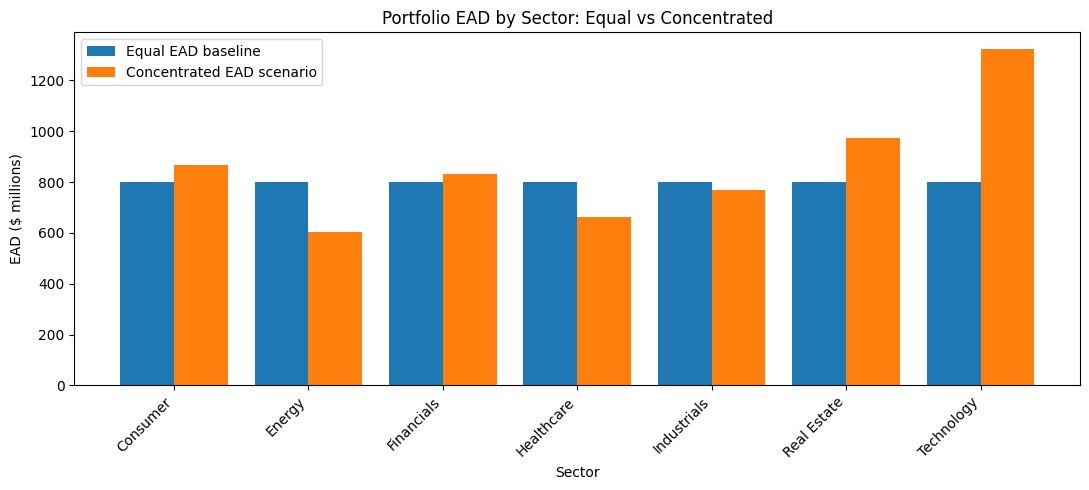

In [35]:
x = np.arange(len(portfolio_summary))
width = 0.40

plt.figure(figsize=(11, 5))
plt.bar(
    x - width / 2,
    portfolio_summary["total_ead_equal_mn"],
    width=width,
    label="Equal EAD baseline"
)
plt.bar(
    x + width / 2,
    portfolio_summary["total_ead_concentrated_mn"],
    width=width,
    label="Concentrated EAD scenario"
)
plt.title("Portfolio EAD by Sector: Equal vs Concentrated")
plt.xlabel("Sector")
plt.ylabel("EAD ($ millions)")
plt.xticks(x, portfolio_summary["sector_group"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


The blue equal-EAD baseline is intentionally flat because each sector has the same number of borrowers and each borrower receives the same exposure. The orange concentrated-EAD scenario is intentionally uneven to show a more realistic wholesale credit portfolio, where facility sizes vary across sectors. The comparison isolates how EAD concentration changes portfolio loss severity while keeping the borrower universe, PDs, LGDs, and correlation structure unchanged.

## 18.1 Single-name and sector exposure concentration check

Before simulating defaults, check whether one borrower or one sector dominates the portfolio.

This matters because a credit portfolio's tail loss can be driven by high borrower PD, high LGD, high default correlation, or simply one very large EAD.

The equal-EAD baseline should have limited single-name concentration. The concentrated-EAD scenario will intentionally introduce more concentration.

Tail risk can be caused by credit quality, correlation, or exposure concentration. This diagnostic checks whether the model results are being mechanically dominated by one large borrower or one sector.

This is especially important when using lognormal EADs because lognormal distributions can create large outliers.

In [36]:
single_name_concentration = merton_inputs[[
    "ticker", "sector_group", "ead_mn", "ead_weight", "pd_model", "lgd"
]].sort_values("ead_weight", ascending=False)

single_name_concentration.head(15)

,ticker,sector_group,ead_mn,ead_weight,pd_model,lgd
0,AAPL,Technology,100.000000,0.017857,0.000100,0.542818
1,MSFT,Technology,100.000000,0.017857,0.000100,0.368511
30,SBUX,Consumer,100.000000,0.017857,0.000100,0.452596
31,NKE,Consumer,100.000000,0.017857,0.000100,0.538888
32,JNJ,Healthcare,100.000000,0.017857,0.000100,0.407200
33,PFE,Healthcare,100.000000,0.017857,0.000100,0.369245
34,MRK,Healthcare,100.000000,0.017857,0.000100,0.422438
35,ABBV,Healthcare,100.000000,0.017857,0.000100,0.390305
36,UNH,Healthcare,100.000000,0.017857,0.000100,0.582424
37,TMO,Healthcare,100.000000,0.017857,0.000100,0.552030


In [37]:
sector_ead_check = portfolio_summary[[
    "sector_group",
    "total_ead_equal_mn",
    "ead_equal_share",
    "total_ead_concentrated_mn",
    "ead_concentrated_share",
    "concentration_ratio_vs_equal"
]].copy()

sector_ead_check.sort_values("ead_concentrated_share", ascending=False)


,sector_group,total_ead_equal_mn,ead_equal_share,total_ead_concentrated_mn,ead_concentrated_share,concentration_ratio_vs_equal
6,Technology,800.000000,0.142857,"1,323.072348",0.219337,1.535360
5,Real Estate,800.000000,0.142857,971.554503,0.161063,1.127441
0,Consumer,800.000000,0.142857,868.636863,0.144001,1.008010
2,Financials,800.000000,0.142857,831.620327,0.137865,0.965054
4,Industrials,800.000000,0.142857,770.072838,0.127662,0.893631
3,Healthcare,800.000000,0.142857,662.499793,0.109828,0.768798
1,Energy,800.000000,0.142857,604.682875,0.100244,0.701705


## 19. Prepare arrays for Monte Carlo simulation

This converts the dataframe into arrays for faster simulation. Each firm gets a default threshold equal to the inverse normal CDF of its PD.

In each scenario, if the simulated latent asset return falls below this threshold, the firm defaults.

In [38]:
# 500,000 paths gives a more stable 99.9% tail estimate than 50,000 paths.
# Lower this number if running on a memory-constrained machine.
n_sims = 500_000

## 19.1 Reusable simulation function

The function below lets us run the same correlated-default simulation under different EAD assumptions:

- equal-EAD baseline,
- concentrated-EAD scenario,
- later stress scenarios.

This keeps the project cleaner and makes scenario comparison easier.

The reusable function lets us run the same simulation under different assumptions, such as equal EAD, concentrated EAD, stressed PDs, or stressed LGDs.

This makes the project easier to extend and keeps scenario comparisons consistent.

In [39]:
def expected_shortfall_from_worst_tail(portfolio_losses, alpha):
    # Average loss in the worst (1 - alpha) fraction of simulations.
    # This avoids a common discrete-loss problem: if VaR is zero, calculating
    # ES as mean(loss | loss >= VaR) accidentally includes nearly every path.
    losses_sorted = np.sort(np.asarray(portfolio_losses))
    n_tail = max(1, int(np.ceil((1 - alpha) * len(losses_sorted))))
    return losses_sorted[-n_tail:].mean()


def run_credit_portfolio_simulation(
    merton_df,
    ead_col="ead_equal",
    n_sims=500_000,
    seed=42,
    chunk_size=100_000,
    store_matrices=True,
):
    rng = np.random.default_rng(seed)
    n_firms = len(merton_df)
    pd_values = merton_df["pd_model"].values
    default_thresholds = norm.ppf(pd_values)
    beta = merton_df["beta_global"].values
    gamma = merton_df["gamma_sector"].values
    idio = merton_df["idio_weight"].values
    ead_lgd = (merton_df[ead_col].values * merton_df["lgd"].values).astype(float)
    sector_names = merton_df["sector_group"].unique()
    sector_index = {sector: idx for idx, sector in enumerate(sector_names)}
    firm_sector_idx = merton_df["sector_group"].map(sector_index).values

    portfolio_losses = np.empty(n_sims, dtype=float)
    losses = np.empty((n_sims, n_firms), dtype=np.float32) if store_matrices else None
    defaults = np.empty((n_sims, n_firms), dtype=bool) if store_matrices else None

    for start in range(0, n_sims, chunk_size):
        end = min(start + chunk_size, n_sims)
        this_chunk = end - start

        M = rng.normal(size=this_chunk)
        sector_factors = rng.normal(size=(this_chunk, len(sector_names)))
        eps = rng.normal(size=(this_chunk, n_firms))

        Y = (
            M[:, None] * beta[None, :]
            + sector_factors[:, firm_sector_idx] * gamma[None, :]
            + eps * idio[None, :]
        )

        defaults_chunk = Y < default_thresholds[None, :]
        losses_chunk = defaults_chunk * ead_lgd[None, :]
        portfolio_losses[start:end] = losses_chunk.sum(axis=1)

        if store_matrices:
            defaults[start:end, :] = defaults_chunk
            losses[start:end, :] = losses_chunk.astype(np.float32)

    return {
        "portfolio_losses": portfolio_losses,
        "losses": losses,
        "defaults": defaults,
        "sector_names": sector_names,
    }


def calculate_risk_metrics(portfolio_losses):
    EL = portfolio_losses.mean()
    UL = portfolio_losses.std()
    VaR_95 = np.quantile(portfolio_losses, 0.95)
    VaR_99 = np.quantile(portfolio_losses, 0.99)
    VaR_999 = np.quantile(portfolio_losses, 0.999)
    ES_95 = expected_shortfall_from_worst_tail(portfolio_losses, 0.95)
    ES_99 = expected_shortfall_from_worst_tail(portfolio_losses, 0.99)
    ES_999 = expected_shortfall_from_worst_tail(portfolio_losses, 0.999)
    economic_capital_999 = VaR_999 - EL
    zero_loss_rate = (portfolio_losses == 0).mean()
    out = pd.DataFrame({
        "metric": [
            "Expected Loss", "Unexpected Loss", "VaR 95%", "VaR 99%", "VaR 99.9%",
            "Expected Shortfall 95%", "Expected Shortfall 99%", "Expected Shortfall 99.9%",
            "Economic Capital 99.9%", "Zero-loss Path Rate"
        ],
        "value": [
            EL, UL, VaR_95, VaR_99, VaR_999,
            ES_95, ES_99, ES_999,
            economic_capital_999, zero_loss_rate
        ]
    })
    out["value_mn"] = np.where(
        out["metric"].eq("Zero-loss Path Rate"),
        np.nan,
        out["value"] / 1e6
    )
    return out


def metric_value(metrics_df, metric_name):
    # Convenience accessor for plotting and attribution code.
    return metrics_df.loc[metrics_df["metric"].eq(metric_name), "value"].iloc[0]

## 19.2 PD-floor sensitivity

The baseline uses a PD floor because many large public companies have very low structural PDs. This sensitivity check shows whether portfolio risk is mostly coming from the Merton estimates or from the floor assumption. The run uses fewer simulations than the final baseline so it stays fast while still revealing the direction of the effect.

In [ ]:
pd_floor_grid = [0.0, 0.00001, 0.00005, 0.00010, 0.00025, 0.00100]
pd_floor_sensitivity_rows = []
pd_floor_sensitivity_sims = min(100_000, n_sims)

for floor in pd_floor_grid:
    floor_df = merton_inputs.copy()
    floor_df["pd_model"] = floor_df["merton_pd"].clip(lower=max(floor, 1e-12))
    floor_results = run_credit_portfolio_simulation(
        floor_df,
        ead_col="ead_equal",
        n_sims=pd_floor_sensitivity_sims,
        seed=2026,
        store_matrices=False,
    )
    floor_metrics = calculate_risk_metrics(floor_results["portfolio_losses"])
    pd_floor_sensitivity_rows.append({
        "pd_floor": floor,
        "mean_model_pd": floor_df["pd_model"].mean(),
        "share_floored": (floor_df["merton_pd"] < floor).mean() if floor > 0 else 0.0,
        "expected_loss_mn": metric_value(floor_metrics, "Expected Loss") / 1e6,
        "var_99_mn": metric_value(floor_metrics, "VaR 99%") / 1e6,
        "var_999_mn": metric_value(floor_metrics, "VaR 99.9%") / 1e6,
        "es_999_mn": metric_value(floor_metrics, "Expected Shortfall 99.9%") / 1e6,
        "zero_loss_rate": metric_value(floor_metrics, "Zero-loss Path Rate"),
    })

pd_floor_sensitivity = pd.DataFrame(pd_floor_sensitivity_rows)
pd_floor_sensitivity

## 20. Simulate correlated defaults

Each simulation path represents one possible one-year economic outcome. The model draws a market shock, sector shocks, and firm-specific shocks, then determines which firms default.

Portfolio loss is the sum of EAD times LGD for all defaulted borrowers in that path.

In [40]:
baseline_results = run_credit_portfolio_simulation(
    merton_inputs,
    ead_col="ead_equal",
    n_sims=n_sims,
    seed=42,
    store_matrices=True
)

portfolio_losses = baseline_results["portfolio_losses"]
losses = baseline_results["losses"]
defaults = baseline_results["defaults"]
sector_names = baseline_results["sector_names"]

print("Baseline equal-EAD simulation complete.")
print("Number of simulations:", f"{n_sims:,}")
print("Zero-loss path rate:", f"{(portfolio_losses == 0).mean():.2%}")
print("Average defaults per path:", f"{defaults.sum(axis=1).mean():.4f}")

portfolio_losses[:10]

Baseline equal-EAD simulation complete.
Number of simulations: 500,000
Zero-loss path rate: 99.43%
Average defaults per path: 0.0057


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## 21. Calculate portfolio risk metrics

Expected Loss is the average simulated loss. VaR measures a high-percentile loss threshold. Expected Shortfall measures the average loss in the worst tail of the simulation.

For discrete credit portfolios, VaR can be zero at common confidence levels if most paths have no defaults. The Expected Shortfall implementation below therefore averages the worst `1 - alpha` fraction of simulation paths, rather than using `mean(loss | loss >= VaR)`, which can be misleading when VaR equals zero.

Economic capital is approximated as 99.9% VaR minus expected loss, representing capital for unexpected extreme credit losses.

In [41]:
risk_metrics = calculate_risk_metrics(portfolio_losses)
VaR_95 = metric_value(risk_metrics, "VaR 95%")
VaR_99 = metric_value(risk_metrics, "VaR 99%")
VaR_999 = metric_value(risk_metrics, "VaR 99.9%")

risk_metrics

,metric,value,value_mn
0,Expected Loss,"269,863.349143",0.269863
1,Unexpected Loss,"3,619,124.102490",3.619124
2,VaR 95%,0.000000,0.000000
3,VaR 99%,0.000000,0.000000
4,VaR 99.9%,"55,203,009.489110",55.203009
5,Expected Shortfall 95%,"5,397,051.100809",5.397051
6,Expected Shortfall 99%,"26,980,938.726521",26.980939
7,Expected Shortfall 99.9%,"58,451,098.832974",58.451099
8,Economic Capital 99.9%,"54,933,146.139968",54.933146
9,Zero-loss Path Rate,0.994298,NaN


## 21.1 Default-count diagnostic

A large spike at zero loss is normal when PDs are low and the portfolio contains a small number of investment-grade public companies.

This diagnostic checks how many firms default in each simulated path.

A large zero-default share is normal for a small low-default portfolio. This diagnostic explains whether the loss distribution is sparse because defaults are rare.

If too few defaults occur in baseline, the right response is to analyze stress scenarios rather than forcing the baseline to look risky.

In [42]:
default_count_distribution = (
    pd.Series(defaults.sum(axis=1), name="default_count")
    .value_counts(normalize=False)
    .sort_index()
    .to_frame("n_paths")
)

default_count_distribution["path_share"] = (
    default_count_distribution["n_paths"] / default_count_distribution["n_paths"].sum()
)

default_count_distribution.head(10)

,n_paths,path_share
0,497149,0.994298
1,2831,0.005662
2,20,0.000040


## 22. Plot portfolio loss distribution

Credit loss distributions are usually skewed with a large mass near zero and a long right tail. The tail is the most important part for capital planning.

This first chart shows the equal-EAD baseline only. A log-frequency y-axis is used because the zero-loss bin is very large. The vertical lines show VaR thresholds. If the 99% VaR is zero, it means at least 99% of simulated paths had zero or negligible loss.

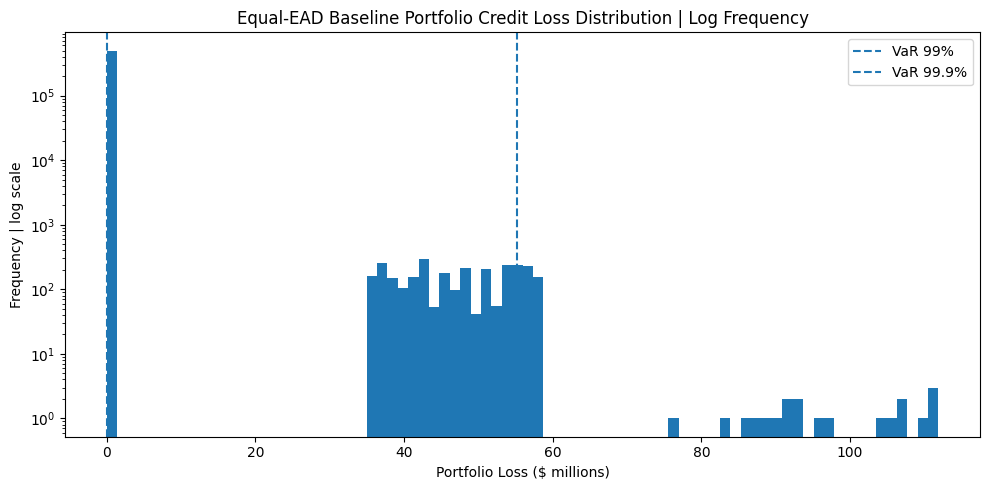

In [43]:
plt.figure(figsize=(10, 5))
plt.hist(portfolio_losses / 1e6, bins=80)
plt.axvline(VaR_99 / 1e6, linestyle="--", label="VaR 99%")
plt.axvline(VaR_999 / 1e6, linestyle="--", label="VaR 99.9%")
plt.yscale("log")
plt.title("Equal-EAD Baseline Portfolio Credit Loss Distribution | Log Frequency")
plt.xlabel("Portfolio Loss ($ millions)")
plt.ylabel("Frequency | log scale")
plt.legend()
plt.tight_layout()
plt.show()

## 23. Tail-risk attribution by sector: Equal-EAD baseline

### Additional explanation
This section asks where extreme losses come from in the equal-EAD baseline. A sector may have modest average loss but a large tail-loss contribution if it has higher PDs, higher LGDs, or stronger factor-driven default clustering.

This is a practical risk-management output because it identifies sectors that drive capital consumption before any exposure-concentration overlay is introduced.

In [44]:
losses_df = pd.DataFrame(losses, columns=merton_inputs["ticker"])

sector_loss_paths = {}

for sector in sector_names:
    sector_tickers = merton_inputs.loc[
        merton_inputs["sector_group"] == sector, "ticker"
    ].tolist()
    sector_loss_paths[sector] = losses_df[sector_tickers].sum(axis=1).values

sector_losses = pd.DataFrame(sector_loss_paths)

# Use the worst 0.1% of simulations for 99.9% tail attribution.
tail_cutoff_index = max(1, int(np.ceil(0.001 * len(portfolio_losses))))
tail_indices_999 = np.argsort(portfolio_losses)[-tail_cutoff_index:]

tail_sector_loss = sector_losses.iloc[tail_indices_999].mean()
expected_sector_loss = sector_losses.mean()

tail_attribution = pd.DataFrame({
    "sector_group": sector_names,
    "expected_loss": [expected_sector_loss[s] for s in sector_names],
    "tail_loss_999": [tail_sector_loss[s] for s in sector_names],
})

tail_attribution["expected_loss_mn"] = tail_attribution["expected_loss"] / 1e6
tail_attribution["tail_loss_999_mn"] = tail_attribution["tail_loss_999"] / 1e6
tail_attribution["tail_loss_share"] = (
    tail_attribution["tail_loss_999"] / tail_attribution["tail_loss_999"].sum()
)

tail_attribution.sort_values("tail_loss_999", ascending=False)

,sector_group,expected_loss,tail_loss_999,expected_loss_mn,tail_loss_999_mn,tail_loss_share
4,Healthcare,"36,323.699219","15,570,867.000000",0.036324,15.570867,0.266362
5,Financials,"43,791.707031","11,875,931.000000",0.043792,11.875931,0.203155
6,Real Estate,"38,970.421875","11,612,807.000000",0.038970,11.612807,0.198654
3,Consumer,"38,091.414062","7,505,194.500000",0.038091,7.505195,0.128387
1,Energy,"39,029.777344","6,438,712.500000",0.039030,6.438713,0.110143
0,Technology,"35,655.921875","4,852,434.500000",0.035656,4.852435,0.083008
2,Industrials,"38,000.429688","601,647.125000",0.038000,0.601647,0.010292


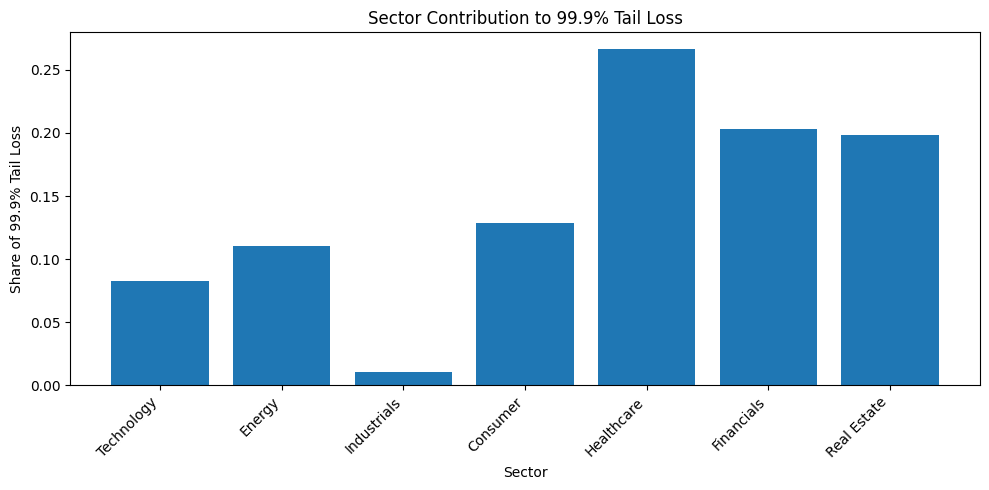

In [45]:
plt.figure(figsize=(10, 5))
plt.bar(tail_attribution["sector_group"], tail_attribution["tail_loss_share"])
plt.title("Sector Contribution to 99.9% Tail Loss")
plt.xlabel("Sector")
plt.ylabel("Share of 99.9% Tail Loss")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 23.1 Concentrated-EAD scenario and comparison diagnostics

The equal-EAD baseline is clean, but real wholesale portfolios are often concentrated.

Now we rerun the same simulation using the capped lognormal EADs. This shows how exposure concentration can change portfolio VaR, Expected Shortfall, and loss severity while leaving the borrower universe and default model unchanged.

The concentrated-EAD scenario intentionally introduces exposure concentration. Comparing it with equal EAD shows whether portfolio risk is driven more by default probabilities/correlation or by large borrower exposures.

Because both scenarios use the same PDs, LGDs, factor loadings, and random seed, the default frequency should be nearly identical. The main difference should appear in loss severity, VaR, Expected Shortfall, and single-name or sector concentration.

In [46]:
concentrated_results = run_credit_portfolio_simulation(
    merton_inputs,
    ead_col="ead_concentrated",
    n_sims=n_sims,
    seed=42,
    store_matrices=False
)

portfolio_losses_conc = concentrated_results["portfolio_losses"]

risk_metrics_conc = calculate_risk_metrics(portfolio_losses_conc)
VaR_99_conc = metric_value(risk_metrics_conc, "VaR 99%")
VaR_999_conc = metric_value(risk_metrics_conc, "VaR 99.9%")

scenario_comparison = risk_metrics["metric"].to_frame().merge(
    risk_metrics[["metric", "value_mn"]].rename(columns={"value_mn": "value_mn_equal_ead"}),
    on="metric"
).merge(
    risk_metrics_conc[["metric", "value_mn"]].rename(columns={"value_mn": "value_mn_concentrated_ead"}),
    on="metric"
)

scenario_comparison

,metric,value_mn_equal_ead,value_mn_concentrated_ead
0,Expected Loss,0.269863,0.279315
1,Unexpected Loss,3.619124,4.394998
2,VaR 95%,0.000000,0.000000
3,VaR 99%,0.000000,0.000000
4,VaR 99.9%,55.203009,75.131410
5,Expected Shortfall 95%,5.397051,5.586079
6,Expected Shortfall 99%,26.980939,27.925927
7,Expected Shortfall 99.9%,58.451099,101.488848
8,Economic Capital 99.9%,54.933146,74.852095
9,Zero-loss Path Rate,NaN,NaN


In [47]:
loss_distribution_diagnostic = pd.DataFrame({
    "scenario": ["Equal EAD", "Concentrated EAD"],
    "zero_loss_rate": [
        (portfolio_losses == 0).mean(),
        (portfolio_losses_conc == 0).mean()
    ],
    "positive_loss_rate": [
        (portfolio_losses > 0).mean(),
        (portfolio_losses_conc > 0).mean()
    ],
    "mean_positive_loss_mn": [
        portfolio_losses[portfolio_losses > 0].mean() / 1e6 if (portfolio_losses > 0).any() else 0,
        portfolio_losses_conc[portfolio_losses_conc > 0].mean() / 1e6 if (portfolio_losses_conc > 0).any() else 0
    ],
    "p99_positive_loss_mn": [
        np.quantile(portfolio_losses[portfolio_losses > 0], 0.99) / 1e6 if (portfolio_losses > 0).any() else 0,
        np.quantile(portfolio_losses_conc[portfolio_losses_conc > 0], 0.99) / 1e6 if (portfolio_losses_conc > 0).any() else 0
    ]
})

loss_distribution_diagnostic


,scenario,zero_loss_rate,positive_loss_rate,mean_positive_loss_mn,p99_positive_loss_mn
0,Equal EAD,0.994298,0.005702,47.327841,58.242441
1,Concentrated EAD,0.994298,0.005702,48.985466,164.176573


The equal-EAD and concentrated-EAD scenarios use the same borrowers, PDs, LGDs, and correlation structure. Therefore, the zero-loss and positive-loss rates should be nearly the same. The important difference is conditional severity: when a default path occurs, concentrated EAD can create much larger losses because exposure is distributed unevenly across names and sectors.

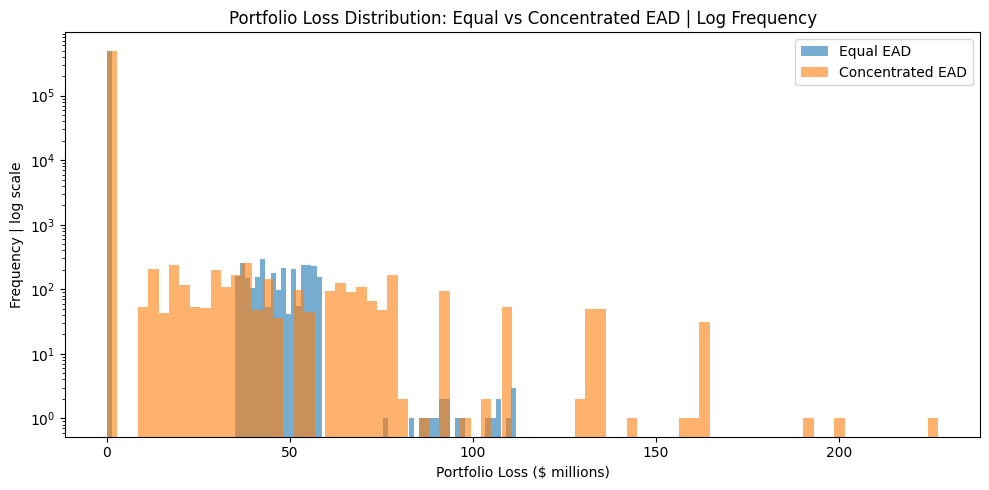

In [48]:
plt.figure(figsize=(10, 5))
plt.hist(portfolio_losses / 1e6, bins=80, alpha=0.6, label="Equal EAD")
plt.hist(portfolio_losses_conc / 1e6, bins=80, alpha=0.6, label="Concentrated EAD")
plt.yscale("log")
plt.title("Portfolio Loss Distribution: Equal vs Concentrated EAD | Log Frequency")
plt.xlabel("Portfolio Loss ($ millions)")
plt.ylabel("Frequency | log scale")
plt.legend()
plt.tight_layout()
plt.show()


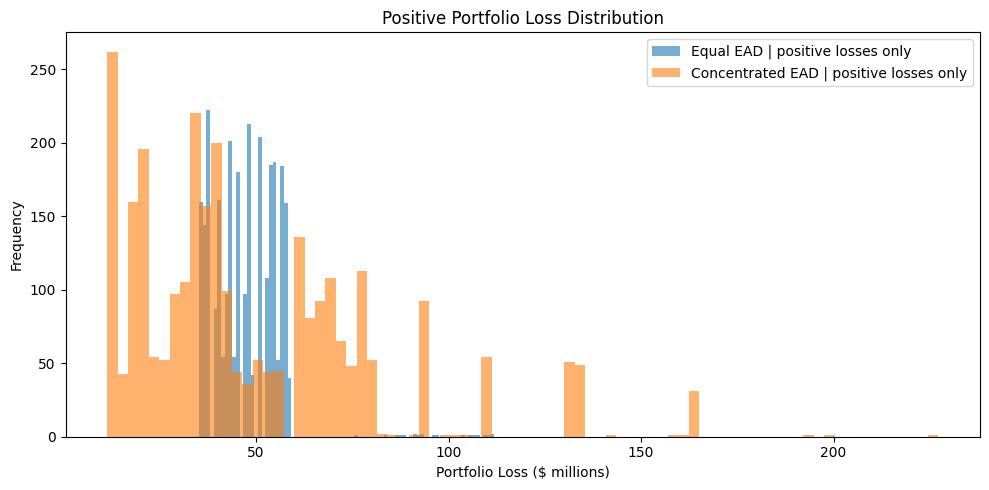

In [49]:
positive_losses = portfolio_losses[portfolio_losses > 0]
positive_losses_conc = portfolio_losses_conc[portfolio_losses_conc > 0]

if len(positive_losses) == 0 and len(positive_losses_conc) == 0:
    print("No positive-loss paths were generated in either scenario.")
else:
    plt.figure(figsize=(10, 5))
    if len(positive_losses) > 0:
        plt.hist(
            positive_losses / 1e6,
            bins=80,
            alpha=0.6,
            label="Equal EAD | positive losses only"
        )
    if len(positive_losses_conc) > 0:
        plt.hist(
            positive_losses_conc / 1e6,
            bins=80,
            alpha=0.6,
            label="Concentrated EAD | positive losses only"
        )
    plt.title("Positive Portfolio Loss Distribution")
    plt.xlabel("Portfolio Loss ($ millions)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()


The log-frequency chart keeps the zero-loss mass visible while making the right tail easier to inspect. The positive-loss-only chart removes the zero-default paths entirely, so it should be used as a conditional-loss diagnostic rather than as the unconditional portfolio loss distribution. Because the two scenarios use the same default model, differences between the charts should be interpreted mainly as EAD-driven severity differences, not changes in default likelihood.

In [50]:
merton_inputs["ead_concentrated_weight"] = (
    merton_inputs["ead_concentrated"] / merton_inputs["ead_concentrated"].sum()
)

concentrated_single_name = merton_inputs[[
    "ticker", "sector_group", "ead_concentrated", "ead_concentrated_weight", "pd_model", "lgd"
]].copy()

concentrated_single_name["ead_concentrated_mn"] = (
    concentrated_single_name["ead_concentrated"] / 1e6
)

concentrated_single_name.sort_values("ead_concentrated_weight", ascending=False).head(15)

,ticker,sector_group,ead_concentrated,ead_concentrated_weight,pd_model,lgd,ead_concentrated_mn
31,NKE,Consumer,"304,658,183.093909",0.050506,0.000100,0.538888,304.658183
6,CSCO,Technology,"302,058,031.694367",0.050075,0.000100,0.432725,302.058032
3,CRM,Technology,"290,409,235.599557",0.048144,0.000100,0.378967,290.409236
20,UNP,Industrials,"278,975,600.399877",0.046248,0.000100,0.480683,278.975600
47,AXP,Financials,"209,590,524.595260",0.034746,0.000100,0.377513,209.590525
54,WELL,Real Estate,"205,792,802.957254",0.034116,0.000100,0.454353,205.792803
55,DLR,Real Estate,"191,917,629.963461",0.031816,0.000100,0.405527,191.917630
34,MRK,Healthcare,"177,851,978.781822",0.029484,0.000100,0.422438,177.851979
7,INTC,Technology,"171,121,613.946593",0.028368,0.000100,0.365890,171.121614
40,JPM,Financials,"167,686,605.188188",0.027799,0.000100,0.550918,167.686605


## 23.2 Stressed-PD scenario

Because the baseline Merton PDs are very low for many large public companies, a mild stress scenario helps reveal the portfolio's loss mechanics at more informative loss quantiles.

This scenario multiplies borrower PDs by five, capped at 5%. It is not a forecast. It is a sensitivity test showing how loss metrics respond when the credit environment deteriorates.

## 23.3 Downturn LGD and macro stress scenarios

A simple PD multiplier is useful, but stress testing is more realistic when defaults, LGDs, and correlations all deteriorate together. The scenarios below combine higher PDs, downturn LGD, and stronger common-factor dependence.

In [51]:
def apply_credit_stress(
    base_df,
    pd_multiplier=1.0,
    pd_addition=0.0,
    pd_cap=0.25,
    lgd_uplift=0.0,
    beta_multiplier=1.0,
    gamma_multiplier=1.0,
    stressed_sectors=None,
    sector_pd_multiplier=1.0,
    sector_lgd_uplift=0.0,
):
    stressed = base_df.copy()
    stressed_sectors = set(stressed_sectors or [])

    stressed["pd_model"] = (stressed["pd_model"] * pd_multiplier + pd_addition).clip(upper=pd_cap)
    stressed["lgd"] = (stressed["lgd"] + lgd_uplift).clip(upper=0.90)

    if stressed_sectors:
        sector_mask = stressed["sector_group"].isin(stressed_sectors)
        stressed.loc[sector_mask, "pd_model"] = (
            stressed.loc[sector_mask, "pd_model"] * sector_pd_multiplier
        ).clip(upper=pd_cap)
        stressed.loc[sector_mask, "lgd"] = (
            stressed.loc[sector_mask, "lgd"] + sector_lgd_uplift
        ).clip(upper=0.90)

    stressed["beta_global"] = stressed["beta_global"] * beta_multiplier
    stressed["gamma_sector"] = stressed["gamma_sector"] * gamma_multiplier
    common_var = stressed["beta_global"]**2 + stressed["gamma_sector"]**2
    max_common_var = 0.90
    scale = np.where(common_var > max_common_var, np.sqrt(max_common_var / common_var), 1.0)
    stressed["beta_global"] = stressed["beta_global"] * scale
    stressed["gamma_sector"] = stressed["gamma_sector"] * scale
    stressed["idio_weight"] = np.sqrt(
        np.maximum(1 - stressed["beta_global"]**2 - stressed["gamma_sector"]**2, 0)
    )
    return stressed


stress_definitions = {
    "Baseline equal EAD": {},
    "Mild recession": {
        "pd_multiplier": 2.0,
        "lgd_uplift": 0.05,
        "beta_multiplier": 1.10,
        "gamma_multiplier": 1.10,
    },
    "Severe recession": {
        "pd_multiplier": 5.0,
        "pd_addition": 0.0005,
        "lgd_uplift": 0.15,
        "beta_multiplier": 1.35,
        "gamma_multiplier": 1.35,
        "pd_cap": 0.10,
    },
    "Real estate and financial shock": {
        "pd_multiplier": 1.5,
        "lgd_uplift": 0.05,
        "beta_multiplier": 1.20,
        "gamma_multiplier": 1.40,
        "stressed_sectors": ["Real Estate", "Financials"],
        "sector_pd_multiplier": 4.0,
        "sector_lgd_uplift": 0.10,
        "pd_cap": 0.12,
    },
}

macro_stress_rows = []
stress_n_sims = min(200_000, n_sims)
stress_loss_paths = {}

for scenario_name, scenario_kwargs in stress_definitions.items():
    scenario_df = apply_credit_stress(merton_inputs, **scenario_kwargs)
    scenario_results = run_credit_portfolio_simulation(
        scenario_df,
        ead_col="ead_equal",
        n_sims=stress_n_sims,
        seed=42,
        store_matrices=False,
    )
    scenario_losses = scenario_results["portfolio_losses"]
    stress_loss_paths[scenario_name] = scenario_losses
    scenario_metrics = calculate_risk_metrics(scenario_losses)
    macro_stress_rows.append({
        "scenario": scenario_name,
        "mean_pd": scenario_df["pd_model"].mean(),
        "mean_lgd": scenario_df["lgd"].mean(),
        "expected_loss_mn": metric_value(scenario_metrics, "Expected Loss") / 1e6,
        "var_99_mn": metric_value(scenario_metrics, "VaR 99%") / 1e6,
        "var_999_mn": metric_value(scenario_metrics, "VaR 99.9%") / 1e6,
        "es_999_mn": metric_value(scenario_metrics, "Expected Shortfall 99.9%") / 1e6,
        "zero_loss_rate": metric_value(scenario_metrics, "Zero-loss Path Rate"),
    })

macro_stress_comparison = pd.DataFrame(macro_stress_rows)

# Backward-compatible names used by the save section.
portfolio_losses_stress = stress_loss_paths["Severe recession"]
risk_metrics_stress = calculate_risk_metrics(portfolio_losses_stress)
stress_scenario_comparison = macro_stress_comparison

macro_stress_comparison

,metric,value_mn_baseline_equal_ead,value_mn_stressed_pd_equal_ead
0,Expected Loss,0.269863,1.336656
1,Unexpected Loss,3.619124,8.134667
2,VaR 95%,0.000000,0.000000
3,VaR 99%,0.000000,50.938937
4,VaR 99.9%,55.203009,58.242441
5,Expected Shortfall 95%,5.397051,26.732055
6,Expected Shortfall 99%,26.980939,58.446137
7,Expected Shortfall 99.9%,58.451099,86.323646
8,Economic Capital 99.9%,54.933146,56.905785
9,Zero-loss Path Rate,NaN,NaN


## 23.4 Executive risk summary

The final summary tables collect the main management-facing outputs: highest-risk borrowers, largest expected-loss contributors, sector tail contributors, and scenario-level capital impact.

In [ ]:
merton_inputs["expected_loss_equal_ead"] = (
    merton_inputs["pd_model"] * merton_inputs["ead_equal"] * merton_inputs["lgd"]
)
merton_inputs["expected_loss_concentrated_ead"] = (
    merton_inputs["pd_model"] * merton_inputs["ead_concentrated"] * merton_inputs["lgd"]
)

top_pd_names = merton_inputs[[
    "ticker", "sector_group", "distance_to_default", "merton_pd", "pd_model",
    "debt_to_equity", "equity_vol", "lgd"
]].sort_values("pd_model", ascending=False).head(10)

top_el_names = merton_inputs[[
    "ticker", "sector_group", "pd_model", "ead_equal", "ead_concentrated", "lgd",
    "expected_loss_equal_ead", "expected_loss_concentrated_ead"
]].sort_values("expected_loss_concentrated_ead", ascending=False).head(10)

executive_summary = pd.DataFrame({
    "item": [
        "Borrowers",
        "Mean model PD",
        "Mean LGD",
        "Equal-EAD expected loss, mn",
        "Equal-EAD VaR 99.9%, mn",
        "Concentrated-EAD VaR 99.9%, mn",
        "Severe recession ES 99.9%, mn",
        "Baseline zero-loss rate",
    ],
    "value": [
        len(merton_inputs),
        merton_inputs["pd_model"].mean(),
        merton_inputs["lgd"].mean(),
        metric_value(risk_metrics, "Expected Loss") / 1e6,
        metric_value(risk_metrics, "VaR 99.9%") / 1e6,
        metric_value(risk_metrics_conc, "VaR 99.9%") / 1e6,
        macro_stress_comparison.loc[
            macro_stress_comparison["scenario"].eq("Severe recession"), "es_999_mn"
        ].iloc[0],
        metric_value(risk_metrics, "Zero-loss Path Rate"),
    ],
})

display(executive_summary)
display(top_pd_names)
display(top_el_names)

## 24. Save final outputs

Saving outputs supports reproducibility and later reporting. Future notebooks can load these CSVs directly for stress testing, governance documentation, and visualization without rerunning data downloads.

In [52]:
PROJECT_DIR = Path(r"C:\Users\Binhe Jia\OneDrive - University of Toronto\Desktop\Credit Risk Research")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

merton_inputs.to_csv(PROJECT_DIR / "firm_level_merton_and_portfolio_inputs.csv", index=False)
pd_floor_diagnostic.to_csv(PROJECT_DIR / "pd_floor_diagnostic.csv", index=False)
sector_ead_check.to_csv(PROJECT_DIR / "sector_ead_check.csv", index=False)
loss_distribution_diagnostic.to_csv(PROJECT_DIR / "loss_distribution_diagnostic.csv", index=False)
risk_metrics.to_csv(PROJECT_DIR / "portfolio_risk_metrics_equal_ead.csv", index=False)
risk_metrics_conc.to_csv(PROJECT_DIR / "portfolio_risk_metrics_concentrated_ead.csv", index=False)
risk_metrics_stress.to_csv(PROJECT_DIR / "portfolio_risk_metrics_stressed_pd.csv", index=False)
scenario_comparison.to_csv(PROJECT_DIR / "portfolio_scenario_comparison.csv", index=False)
stress_scenario_comparison.to_csv(PROJECT_DIR / "portfolio_stressed_pd_scenario_comparison.csv", index=False)
pd_floor_sensitivity.to_csv(PROJECT_DIR / "pd_floor_sensitivity.csv", index=False)
macro_stress_comparison.to_csv(PROJECT_DIR / "macro_stress_comparison.csv", index=False)
executive_summary.to_csv(PROJECT_DIR / "executive_summary.csv", index=False)
top_pd_names.to_csv(PROJECT_DIR / "top_pd_names.csv", index=False)
top_el_names.to_csv(PROJECT_DIR / "top_expected_loss_names.csv", index=False)
tail_attribution.to_csv(PROJECT_DIR / "sector_tail_risk_attribution_equal_ead.csv", index=False)

pd.Series(portfolio_losses, name="portfolio_loss_equal_ead").to_csv(
    "portfolio_loss_simulations_equal_ead.csv",
    index=False
)

pd.Series(portfolio_losses_conc, name="portfolio_loss_concentrated_ead").to_csv(
    "portfolio_loss_simulations_concentrated_ead.csv",
    index=False
)

pd.Series(portfolio_losses_stress, name="portfolio_loss_stressed_pd_equal_ead").to_csv(
    "portfolio_loss_simulations_stressed_pd.csv",
    index=False
)

print("Saved:")
print("Output folder:", PROJECT_DIR)
print("- firm_level_merton_and_portfolio_inputs.csv")
print("- pd_floor_diagnostic.csv")
print("- sector_ead_check.csv")
print("- loss_distribution_diagnostic.csv")
print("- portfolio_risk_metrics_equal_ead.csv")
print("- portfolio_risk_metrics_concentrated_ead.csv")
print("- portfolio_risk_metrics_stressed_pd.csv")
print("- portfolio_scenario_comparison.csv")
print("- portfolio_stressed_pd_scenario_comparison.csv")
print("- pd_floor_sensitivity.csv")
print("- macro_stress_comparison.csv")
print("- executive_summary.csv")
print("- top_pd_names.csv")
print("- top_expected_loss_names.csv")
print("- sector_tail_risk_attribution_equal_ead.csv")
print("- portfolio_loss_simulations_equal_ead.csv")
print("- portfolio_loss_simulations_concentrated_ead.csv")
print("- portfolio_loss_simulations_stressed_pd.csv")


Saved:
- firm_level_merton_and_portfolio_inputs.csv
- pd_floor_diagnostic.csv
- sector_ead_check.csv
- loss_distribution_diagnostic.csv
- portfolio_risk_metrics_equal_ead.csv
- portfolio_risk_metrics_concentrated_ead.csv
- portfolio_risk_metrics_stressed_pd.csv
- portfolio_scenario_comparison.csv
- portfolio_stressed_pd_scenario_comparison.csv
- sector_tail_risk_attribution_equal_ead.csv
- portfolio_loss_simulations_equal_ead.csv
- portfolio_loss_simulations_concentrated_ead.csv
- portfolio_loss_simulations_stressed_pd.csv
